In [ ]:
# Instalación de librerías necesarias
!pip install pandas matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


In [ ]:
np.random.seed(42)
n = 200

data = {
    'nombre': [f'Candidato_{i}' for i in range(n)],
    'genero': np.random.choice(['Masculino', 'Femenino'], n, p=[0.55, 0.45]),
    'edad': np.random.randint(22, 60, n),
    'anos_experiencia': np.random.randint(0, 30, n),
    'nivel_educacion': np.random.choice(['Bachillerato', 'Licenciatura', 'Maestria', 'Doctorado'], n),
    'departamento': np.random.choice(['Tecnologia', 'Ventas', 'RRHH', 'Operaciones', 'Marketing'], n),
    'salario_ofertado': np.random.randint(25000, 120000, n),
    'contratado': np.random.choice([0, 1], n, p=[0.45, 0.55])
}

df = pd.DataFrame(data)

mask_fem_tech = (df['genero'] == 'Femenino') & (df['departamento'] == 'Tecnologia')
df.loc[mask_fem_tech, 'contratado'] = np.random.choice([0, 1], mask_fem_tech.sum(), p=[0.70, 0.30])

mask_edad = df['edad'] > 45
df.loc[mask_edad, 'contratado'] = np.random.choice([0, 1], mask_edad.sum(), p=[0.65, 0.35])

df.loc[df['genero'] == 'Femenino', 'salario_ofertado'] = (
    df.loc[df['genero'] == 'Femenino', 'salario_ofertado'] * 0.85
).astype(int)

print("Dataset creado exitosamente")
print(f"Total de candidatos: {len(df)}")
print(f"\nPrimeros 5 registros:")
df.head()

Dataset creado exitosamente
Total de candidatos: 200

Primeros 5 registros:


,nombre,genero,edad,anos_experiencia,nivel_educacion,departamento,salario_ofertado,contratado
0,Candidato_0,Masculino,45,28,Licenciatura,Ventas,36246,1
1,Candidato_1,Femenino,32,25,Maestria,Marketing,59974,1
2,Candidato_2,Femenino,29,9,Maestria,Ventas,36873,1
3,Candidato_3,Femenino,57,25,Bachillerato,Marketing,52236,0
4,Candidato_4,Masculino,59,29,Bachillerato,RRHH,117263,0


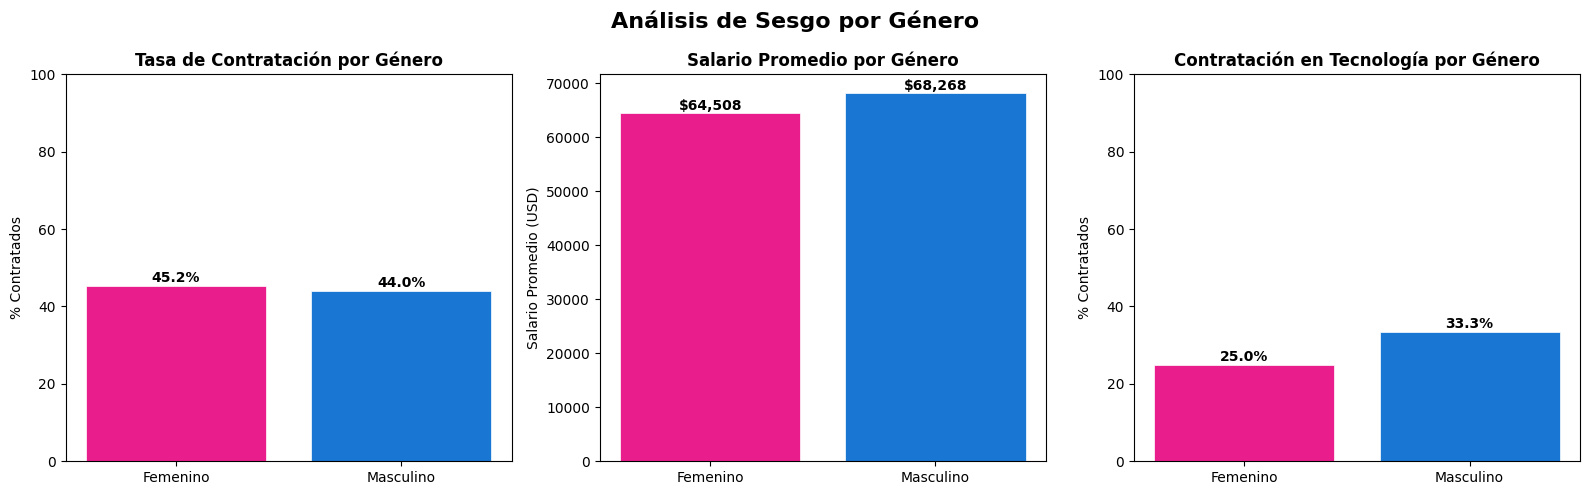


Resumen de hallazgos:
Brecha salarial: 5.5% menos para mujeres
Brecha de contratación general: -1.3 puntos porcentuales
Brecha en Tecnología: 8.3 puntos porcentuales


In [ ]:
# ANÁLISIS DE SESGO POR GÉNERO
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Sesgo por Género', fontsize=16, fontweight='bold')

# Gráfico 1: Tasa de contratación por género
contratacion_genero = df.groupby('genero')['contratado'].mean() * 100
axes[0].bar(contratacion_genero.index, contratacion_genero.values,
            color=['#E91E8C', '#1976D2'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Tasa de Contratación por Género', fontweight='bold')
axes[0].set_ylabel('% Contratados')
axes[0].set_ylim(0, 100)
for i, v in enumerate(contratacion_genero.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Gráfico 2: Salario promedio por género
salario_genero = df.groupby('genero')['salario_ofertado'].mean()
axes[1].bar(salario_genero.index, salario_genero.values,
            color=['#E91E8C', '#1976D2'], edgecolor='white', linewidth=0.5)
axes[1].set_title('Salario Promedio por Género', fontweight='bold')
axes[1].set_ylabel('Salario Promedio (USD)')
for i, v in enumerate(salario_genero.values):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

# Gráfico 3: Contratación por género en Tecnología
tech_df = df[df['departamento'] == 'Tecnologia']
tech_genero = tech_df.groupby('genero')['contratado'].mean() * 100
axes[2].bar(tech_genero.index, tech_genero.values,
            color=['#E91E8C', '#1976D2'], edgecolor='white', linewidth=0.5)
axes[2].set_title('Contratación en Tecnología por Género', fontweight='bold')
axes[2].set_ylabel('% Contratados')
axes[2].set_ylim(0, 100)
for i, v in enumerate(tech_genero.values):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sesgo_genero.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResumen de hallazgos:")
print(f"Brecha salarial: {((salario_genero['Masculino'] - salario_genero['Femenino']) / salario_genero['Masculino'] * 100):.1f}% menos para mujeres")
print(f"Brecha de contratación general: {(contratacion_genero['Masculino'] - contratacion_genero['Femenino']):.1f} puntos porcentuales")
print(f"Brecha en Tecnología: {(tech_genero['Masculino'] - tech_genero['Femenino']):.1f} puntos porcentuales")

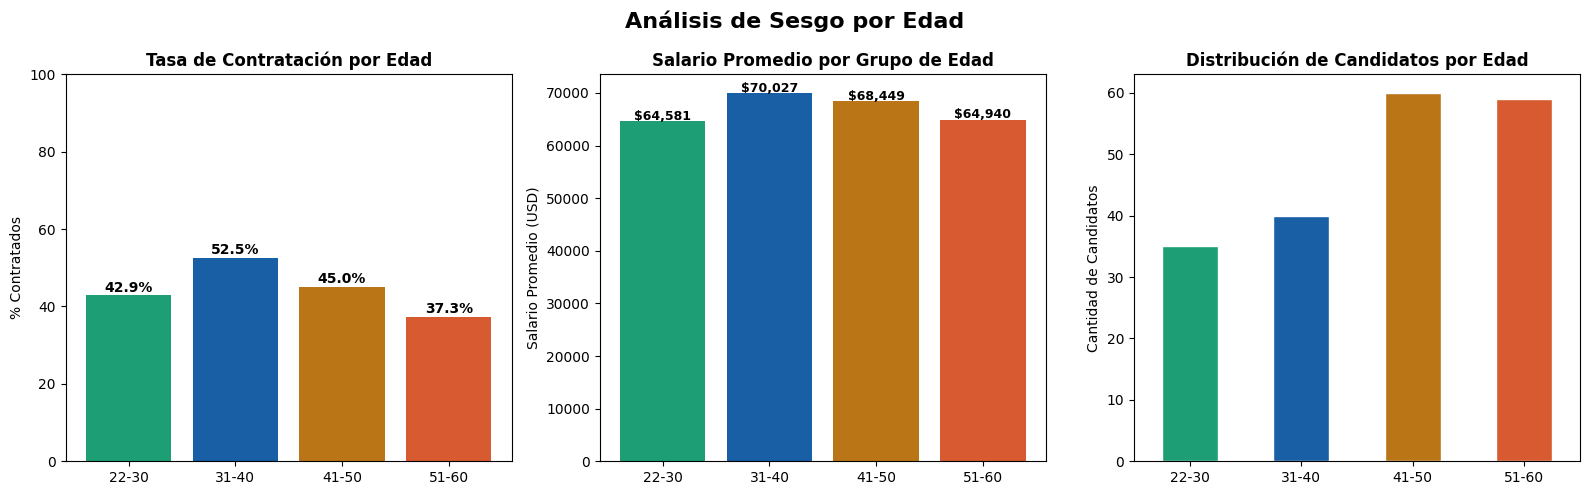


Resumen de hallazgos por edad:
Grupo 22-30: 42.9% contratados — Salario promedio: $64,581
Grupo 31-40: 52.5% contratados — Salario promedio: $70,027
Grupo 41-50: 45.0% contratados — Salario promedio: $68,449
Grupo 51-60: 37.3% contratados — Salario promedio: $64,940

Brecha de contratación (22-30 vs 51-60): 5.6 puntos porcentuales


In [ ]:
# ANÁLISIS DE SESGO POR EDAD
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Sesgo por Edad', fontsize=16, fontweight='bold')

# Grupos de edad
df['grupo_edad'] = pd.cut(df['edad'],
                           bins=[22, 30, 40, 50, 60],
                           labels=['22-30', '31-40', '41-50', '51-60'])

# Gráfico 1: Tasa de contratación por grupo de edad
contratacion_edad = df.groupby('grupo_edad', observed=True)['contratado'].mean() * 100
axes[0].bar(contratacion_edad.index, contratacion_edad.values,
            color=['#1D9E75', '#185FA5', '#BA7517', '#D85A30'])
axes[0].set_title('Tasa de Contratación por Edad', fontweight='bold')
axes[0].set_ylabel('% Contratados')
axes[0].set_ylim(0, 100)
for i, v in enumerate(contratacion_edad.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Gráfico 2: Salario promedio por grupo de edad
salario_edad = df.groupby('grupo_edad', observed=True)['salario_ofertado'].mean()
axes[1].bar(salario_edad.index, salario_edad.values,
            color=['#1D9E75', '#185FA5', '#BA7517', '#D85A30'])
axes[1].set_title('Salario Promedio por Grupo de Edad', fontweight='bold')
axes[1].set_ylabel('Salario Promedio (USD)')
for i, v in enumerate(salario_edad.values):
    axes[1].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Gráfico 3: Distribución de candidatos por edad
df['grupo_edad'].value_counts().sort_index().plot(kind='bar', ax=axes[2],
    color=['#1D9E75', '#185FA5', '#BA7517', '#D85A30'], edgecolor='white')
axes[2].set_title('Distribución de Candidatos por Edad', fontweight='bold')
axes[2].set_ylabel('Cantidad de Candidatos')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('sesgo_edad.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResumen de hallazgos por edad:")
for grupo in contratacion_edad.index:
    print(f"Grupo {grupo}: {contratacion_edad[grupo]:.1f}% contratados — Salario promedio: ${salario_edad[grupo]:,.0f}")

jovenes = contratacion_edad['22-30']
mayores = contratacion_edad['51-60']
print(f"\nBrecha de contratación (22-30 vs 51-60): {(jovenes - mayores):.1f} puntos porcentuales")

In [ ]:
print("=" * 60)
print("INFORME DE ETICA Y SESGO EN IA")
print("Analisis de Datos de Contratacion")
print("=" * 60)

print("\nSESGOS IDENTIFICADOS")
print("-" * 40)
print("1. SESGO DE GENERO")
print("   Brecha salarial: Las mujeres reciben 5.5% menos salario.")
print("   En Tecnologia, hombres tienen 8.3 puntos mas de contratacion.")
print("   Un modelo de IA entrenado con estos datos perpetuaria estas desigualdades.")
print("\n2. SESGO DE EDAD")
print("   Candidatos 51-60 tienen la tasa mas baja: 37.3%")
print("   Candidatos 31-40 son los mas favorecidos: 52.5%")
print("   Brecha de 5.6 puntos entre grupo joven y mayor.")
print("   Un modelo predictivo discriminaria a candidatos mayores de 45.")

print("\nRECOMENDACIONES ETICAS")
print("-" * 40)
recomendaciones = [
    "Auditar regularmente los datos de entrenamiento para detectar sesgos.",
    "Eliminar variables como genero y edad de modelos de seleccion.",
    "Implementar metricas de equidad: igualdad de oportunidades y paridad demografica.",
    "Crear comites de revision humana para decisiones asistidas por IA.",
    "Establecer politicas de transparencia para candidatos rechazados.",
    "Realizar auditorias externas periodicas con enfoque en grupos protegidos.",
]

for i, rec in enumerate(recomendaciones, 1):
    print(f"\n{i}. {rec}")

print("\nCONCLUSION FINAL")
print("-" * 40)
print("Los datos contienen sesgos sistematicos por genero y edad.")
print("Si se usan para entrenar modelos de IA, produciran decisiones")
print("discriminatorias a escala. La etica en IA es una responsabilidad")
print("organizacional y social.")
print("\nProyecto: Modulo 7 - Etica y Sesgo en IA")
print("INDOTEL / BID / CYMETRIA 2026 — Yasmin Beltre")
print("=" * 60)

with open('informe_etica_sesgo_ia.txt', 'w', encoding='utf-8') as f:
    f.write("INFORME DE ETICA Y SESGO EN IA\n")
    f.write("Yasmin Beltre — INDOTEL / BID / CYMETRIA 2026\n\n")
    f.write("Sesgos identificados:\n")
    f.write("- Brecha salarial de genero: 5.5%\n")
    f.write("- Brecha contratacion en Tecnologia: 8.3 puntos\n")
    f.write("- Brecha contratacion por edad (22-30 vs 51-60): 5.6 puntos\n\n")
    f.write("Ver notebook completo para analisis detallado.\n")

print("\nArchivo guardado exitosamente")

INFORME DE ETICA Y SESGO EN IA
Analisis de Datos de Contratacion

SESGOS IDENTIFICADOS
----------------------------------------
1. SESGO DE GENERO
   Brecha salarial: Las mujeres reciben 5.5% menos salario.
   En Tecnologia, hombres tienen 8.3 puntos mas de contratacion.
   Un modelo de IA entrenado con estos datos perpetuaria estas desigualdades.

2. SESGO DE EDAD
   Candidatos 51-60 tienen la tasa mas baja: 37.3%
   Candidatos 31-40 son los mas favorecidos: 52.5%
   Brecha de 5.6 puntos entre grupo joven y mayor.
   Un modelo predictivo discriminaria a candidatos mayores de 45.

RECOMENDACIONES ETICAS
----------------------------------------

1. Auditar regularmente los datos de entrenamiento para detectar sesgos.

2. Eliminar variables como genero y edad de modelos de seleccion.

3. Implementar metricas de equidad: igualdad de oportunidades y paridad demografica.

4. Crear comites de revision humana para decisiones asistidas por IA.

5. Establecer politicas de transparencia para can